In [62]:

import os
os.environ["CRDS_PATH"] = os.path.expanduser("~/crds_cache")
os.makedirs(os.environ["CRDS_PATH"], exist_ok=True)

os.environ["CRDS_SERVER_URL"] = "https://jwst-crds.stsci.edu"
os.environ["CRDS_CONTEXT"] = "jwst_1460.pmap"
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astroquery.svo_fps import SvoFps
from astropy.wcs import WCS
from astropy.io import fits
from extinction import apply
from astropy.modeling import models
import extinction
from dust_extinction.averages import RL85_MWGC
import matplotlib.gridspec as gridspec
from astropy.visualization import simple_norm

from dust_extinction.averages import RL85_MWGC, G21_MWAvg
from dust_extinction.parameter_averages import CCM89
ext = RL85_MWGC()
ext = G21_MWAvg()
plt.rcParams['axes.labelsize']=20
plt.rcParams['xtick.labelsize']=15
plt.rcParams['ytick.labelsize']=15
def get_mag(catalog, ww, filtername='f140m'):
    print(ww.proj_plane_pixel_area())
    flux= (catalog['flux_fit_' + filtername] * u.MJy/u.sr * ww.proj_plane_pixel_area()).to(u.Jy)
    eflux_jy = (catalog['flux_err_' + filtername] * u.MJy/u.sr *  ww.proj_plane_pixel_area()).to(u.Jy)

    jfilts = SvoFps.get_filter_list('JWST')
    jfilts.add_index('filterID')
    zeropoint = u.Quantity(jfilts.loc[f'JWST/NIRCam.{filtername.upper()}']['ZeroPoint'], u.Jy)
    abmag = -2.5 * np.log10(flux / zeropoint) * u.mag
    abmag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    return abmag, abmag_err

def plot_extvec_ccd(ax, color1, color2, ext=RL85_MWGC(), extvec_scale=200,
                    start=(0, 0),
                    color='y', head_width=0.5):
    def get_wave(c):
        if c == '410m405': return 4.10*u.um
        if c == '405m410': return 4.05*u.um
        if c == 'Hmag': return 1.634*u.um
        if c == 'Ksmag': return 2.143527*u.um
        return int(c[1:-1])/100*u.um

    w1 = get_wave(color1[0])
    w2 = get_wave(color1[1])
    w3 = get_wave(color2[0])
    w4 = get_wave(color2[1])

    if w1 > w2:
        w1, w2 = w2, w1
        color1 = color1[::-1]
    if w3 > w4:
        w3, w4 = w4, w3
        color2 = color2[::-1]
    print(w1,w2,w3,w4)

    # Only plot if all are in valid range
    try:
        e_1 = ext(1/w1) * extvec_scale
        e_2 = ext(1/w2) * extvec_scale
        e_3 = ext(1/w3) * extvec_scale
        e_4 = ext(1/w4) * extvec_scale
    except ValueError as e:
        print(f"Extinction vector not plotted: {e}")
        return
    print(w1,w2,w3,w4)
    print(e_1, e_2, e_3, e_4)
    ax.annotate(f'$A_V={extvec_scale}$', xy=(start[0] + (e_1 - e_2), start[1] + (e_3 - e_4)),
                xytext=(start[0], start[1]),
                arrowprops=dict(arrowstyle='-|>', color=color,
                                shrinkA=0, shrinkB=0,
                                mutation_scale=20, linewidth=1.5))
    ax.plot([], [], color=color, marker='>', markersize=8,
            label=f'$A_V={extvec_scale}$', linestyle='-', linewidth=2)

from astropy.table import Table
import crds
parsec_av0 = Table.read('/home/t.yoo/parsec_av0.txt', format='ascii')
parsec_av0.pprint(max_width=-1, max_lines=-1)    
m_init = parsec_av0['col4']  
parsec_av0 = parsec_av0[m_init<300]                    
logage_av0 = parsec_av0['col3']
mass_av0 = parsec_av0['col6']
F140Mmag_av0 = parsec_av0['col39'] + 5*np.log10(5400)-5
F162Mmag_av0 = parsec_av0['col40']+ 5*np.log10(5400)-5
F182Mmag_av0 = parsec_av0['col41']+ 5*np.log10(5400)-5
F187Nmag_av0 = parsec_av0['col44']+ 5*np.log10(5400)-5
F210Mmag_av0 = parsec_av0['col42']+ 5*np.log10(5400)-5
F335Mmag_av0 = parsec_av0['col45']+ 5*np.log10(5400)-5
F360Mmag_av0 = parsec_av0['col46']+ 5*np.log10(5400)-5
F410Mmag_av0 = parsec_av0['col47']+ 5*np.log10(5400)-5
F480Mmag_av0 = parsec_av0['col50']+ 5*np.log10(5400)-5

parsec_av5 = Table.read('/home/t.yoo/parsec_av5.txt', format='ascii')
logage_av5 = parsec_av5['col3']
mass_av5 = parsec_av5['col6']
F140Mmag_av5 = parsec_av5['col39']+ 5*np.log10(5400)-5
F162Mmag_av5 = parsec_av5['col40'] + 5*np.log10(5400)-5
F182Mmag_av5 = parsec_av5['col41']+ 5*np.log10(5400)-5
F187Mmag_av5 = parsec_av5['col44']+ 5*np.log10(5400)-5
F210Mmag_av5 = parsec_av5['col42']+ 5*np.log10(5400)-5
F335Mmag_av5 = parsec_av5['col45']+ 5*np.log10(5400)-5
F360Mmag_av5 = parsec_av5['col46']+ 5*np.log10(5400)-5
F410Mmag_av5 = parsec_av5['col47']+ 5*np.log10(5400)-5
F480Mmag_av5 = parsec_av5['col50']+ 5*np.log10(5400)-5

parsec_av10 = Table.read('/home/t.yoo/parsec_av10.txt', format='ascii')
logage_av10 = parsec_av10['col3']
mass_av10 = parsec_av10['col6']
F140Mmag_av10 = parsec_av10['col39']+ 5*np.log10(5400)-5
F162Mmag_av10 = parsec_av10['col40']+ 5*np.log10(5400)-5
F182Mmag_av10 = parsec_av10['col41']+ 5*np.log10(5400)-5
F187Nmag_av10 = parsec_av10['col44']+ 5*np.log10(5400)-5
F210Mmag_av10 = parsec_av10['col42']+ 5*np.log10(5400)-5
F335Mmag_av10 = parsec_av10['col45']+ 5*np.log10(5400)-5
F360Mmag_av10 = parsec_av10['col46']+ 5*np.log10(5400)-5
F410Mmag_av10 = parsec_av10['col47']+ 5*np.log10(5400)-5
F480Mmag_av10 = parsec_av10['col50']+ 5*np.log10(5400)-5


import asdf

def load_nircam_abvega_offsets(asdf_path, filter_name):
    """
    Load JWST NIRCam AB–Vega offset reference file (ASDF) 
    and return a dict mapping filter names → offsets (in mag).
    
    The ASDF file is expected to follow the JWST CRDS “FILTEROFFSET”
    (or an equivalent zeropoint offset) schema.
    """
    with asdf.open(asdf_path) as af:
        tree = af.tree
        # The offsets might live under some key, e.g. tree["offsets"] or tree["filters"]
        # Inspect the file structure to adapt:
        # For example, tree["data"] or tree["offsets"] or tree["filters"]
        # Here’s a guess:
        tabs = tree.get("abvega_offset", None)
        idx = np.where((tabs['filter'] == filter_name.upper()) & (tabs['pupil']=='CLEAR'))[0]
        if len(idx)!=1:
            idx = np.where(tabs['pupil']==filter_name.upper())[0]
        tabs.pprint(max_width=-1, max_lines=-1)
        print(idx)
        return tabs['abvega_offset'][idx].item()


def vega_to_ab(vega_mag, filter_name, asdf_path):
    """
    Convert Vega magnitude to AB magnitude using offset dictionary.
    """
    offset = load_nircam_abvega_offsets(asdf_path, filter_name)
   
    return vega_mag + offset

"""
from astropy.io import fits
hdr = fits.getheader(image_filenames['f140m'], ext=('SCI', 1))
print(hdr)
crds_params = {
    "INSTRUME": "NIRCAM",
    "DETECTOR": 'NRCA1',  # or NRCB5, etc.
    "META.OBSERVATION.DATE": hdr['DATE-OBS']  # Use the actual observation date
}

# Path or URL to your .rmap file
ref_file = crds.getreferences(crds_params, ["abvegaoffset"], context="jwst_1460.pmap")

rmap = crds.rmap.load_mapping(ref_file["nircam_abvegaoffset"]
)
references = rmap.get_data()
"""
#asdf_file = crds.get_reference_file("jwst", refname)
asdf_file = '/home/t.yoo/w51/w51_nircam/jwst_nircam_abvegaoffset_0002.asdf'
F140M_avmag_av0 = vega_to_ab(F140Mmag_av0, 'F140M', asdf_file)
F162M_avmag_av0 = vega_to_ab(F162Mmag_av0, 'F162M', asdf_file)
F182M_avmag_av0 = vega_to_ab(F182Mmag_av0, 'F182M', asdf_file)
F187N_avmag_av0 = vega_to_ab(F187Nmag_av0, 'F187N', asdf_file)
F210M_avmag_av0 = vega_to_ab(F210Mmag_av0, 'F210M', asdf_file)
F335M_avmag_av0 = vega_to_ab(F335Mmag_av0, 'F335M', asdf_file)
F360M_avmag_av0 = vega_to_ab(F360Mmag_av0, 'F360M', asdf_file)
F410M_avmag_av0 = vega_to_ab(F410Mmag_av0, 'F410M', asdf_file)
F480M_avmag_av0 = vega_to_ab(F480Mmag_av0, 'F480M', asdf_file)

F140M_avmag_av5 = vega_to_ab(F140Mmag_av5, 'F140M', asdf_file)
F162M_avmag_av5 = vega_to_ab(F162Mmag_av5, 'F162M', asdf_file)
F182M_avmag_av5 = vega_to_ab(F182Mmag_av5, 'F182M', asdf_file)
F187M_avmag_av5 = vega_to_ab(F187Mmag_av5, 'F187N', asdf_file)
F210M_avmag_av5 = vega_to_ab(F210Mmag_av5, 'F210M', asdf_file)
F335M_avmag_av5 = vega_to_ab(F335Mmag_av5, 'F335M', asdf_file)
F360M_avmag_av5 = vega_to_ab(F360Mmag_av5, 'F360M', asdf_file)
F410M_avmag_av5 = vega_to_ab(F410Mmag_av5, 'F410M', asdf_file)
F480M_avmag_av5 = vega_to_ab(F480Mmag_av5, 'F480M', asdf_file)

F140M_avmag_av10 = vega_to_ab(F140Mmag_av10, 'F140M', asdf_file)
F162M_avmag_av10 = vega_to_ab(F162Mmag_av10, 'F162M', asdf_file)
F182M_avmag_av10 = vega_to_ab(F182Mmag_av10, 'F182M', asdf_file)
F187N_avmag_av10 = vega_to_ab(F187Nmag_av10, 'F187N', asdf_file)
F210M_avmag_av10 = vega_to_ab(F210Mmag_av10, 'F210M', asdf_file)
F335M_avmag_av10 = vega_to_ab(F335Mmag_av10, 'F335M', asdf_file)
F360M_avmag_av10 = vega_to_ab(F360Mmag_av10, 'F360M', asdf_file)
F410M_avmag_av10 = vega_to_ab(F410Mmag_av10, 'F410M', asdf_file)
F480M_avmag_av10 = vega_to_ab(F480Mmag_av10, 'F480M', asdf_file)


    


catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_nircam_indivexp_merged_dao_refined.fits')
catalog_new = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_nircam_indivexp_merged_dao_refined_after_sat.fits')
image_filenames ={
    "f140m": "/orange/adamginsburg/jwst/w51/F140M/pipeline/jw06151-o001_t001_nircam_clear-f140m-merged_i2d.fits",
    "f150w": "/orange/adamginsburg/jwst/w51/F150W/pipeline/jw06151-o001_t001_nircam_clear-f150w-merged_i2d.fits",
    "f162m": "/orange/adamginsburg/jwst/w51/F162M/pipeline/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f182m": "/orange/adamginsburg/jwst/w51/F182M/pipeline/jw06151-o001_t001_nircam_clear-f182m-merged_i2d.fits",
    "f187n": "/orange/adamginsburg/jwst/w51/F187N/pipeline/jw06151-o001_t001_nircam_clear-f187n-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/F210M/pipeline/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f335m": "/orange/adamginsburg/jwst/w51/F335M/pipeline/jw06151-o001_t001_nircam_clear-f335m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/F360M/pipeline/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f405n": "/orange/adamginsburg/jwst/w51/F405N/pipeline/jw06151-o001_t001_nircam_clear-f405n-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/w51/F410M/pipeline/jw06151-o001_t001_nircam_clear-f410m-merged_i2d.fits", # weird, the filename is different from what is downloaded with the STScI pipeline...
    "f480m": "/orange/adamginsburg/jwst/w51/F480M/pipeline/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
    "f560w": "/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_i2d.fits",
    "f770w": "/orange/adamginsburg/jwst/w51/F770W/pipeline/jw06151-o002_t001_miri_f770w_i2d.fits",
    "f1000w": "/orange/adamginsburg/jwst/w51/F1000W/pipeline/jw06151-o002_t001_miri_f1000w_i2d.fits",
    "f1280w": "/orange/adamginsburg/jwst/w51/F1280W/pipeline/jw06151-o002_t001_miri_f1280w_i2d.fits",
    "f1500w": "/orange/adamginsburg/jwst/w51/F1500W/pipeline/jw06151-o002_t001_miri_f1500w_i2d.fits",
    "f2100w": "/orange/adamginsburg/jwst/w51/F2100W/pipeline/jw06151-o002_t001_miri_f2100w_i2d.fits",
    
}

f140m_header = fits.getheader(image_filenames['f140m'], ext=('SCI', 1))
f162m_header = fits.getheader(image_filenames['f162m'], ext=('SCI', 1))
f182m_header = fits.getheader(image_filenames['f182m'], ext=('SCI', 1))
f187n_header = fits.getheader(image_filenames['f187n'], ext=('SCI', 1))
f210m_header = fits.getheader(image_filenames['f210m'], ext=('SCI', 1))
f335m_header = fits.getheader(image_filenames['f335m'], ext=('SCI', 1))
f360m_header = fits.getheader(image_filenames['f360m'], ext=('SCI', 1))
f405n_header = fits.getheader(image_filenames['f405n'], ext=('SCI', 1))
f410m_header = fits.getheader(image_filenames['f410m'], ext=('SCI', 1))
f480m_header = fits.getheader(image_filenames['f480m'], ext=('SCI', 1))

f140m_mag, f140m_magerr = get_mag(catalog, WCS(f140m_header), filtername='f140m')
f162m_mag, f162m_magerr = get_mag(catalog, WCS(f162m_header), filtername='f162m')
f182m_mag, f182m_magerr = get_mag(catalog, WCS(f182m_header), filtername='f182m')
f187n_mag, f187n_magerr = get_mag(catalog, WCS(f187n_header), filtername='f187n')
f210m_mag, f210m_magerr = get_mag(catalog, WCS(f210m_header), filtername='f210m')
f335m_mag, f335m_magerr = get_mag(catalog, WCS(f335m_header), filtername='f335m')
f360m_mag, f360m_magerr = get_mag(catalog, WCS(f360m_header), filtername='f360m')
f405n_mag, f405n_magerr = get_mag(catalog, WCS(f405n_header), filtername='f405n')
f410m_mag, f410m_magerr = get_mag(catalog, WCS(f410m_header), filtername='f410m')
f480m_mag, f480m_magerr = get_mag(catalog, WCS(f480m_header), filtername='f480m')


f140m_mag_new, f140m_magerr = get_mag(catalog_new, WCS(f140m_header), filtername='f140m')
f162m_mag_new, f162m_magerr = get_mag(catalog_new, WCS(f162m_header), filtername='f162m')
f182m_mag_new, f182m_magerr = get_mag(catalog_new, WCS(f182m_header), filtername='f182m')
f187n_mag_new, f187n_magerr = get_mag(catalog_new, WCS(f187n_header), filtername='f187n')
f210m_mag_new, f210m_magerr = get_mag(catalog_new, WCS(f210m_header), filtername='f210m')
f335m_mag_new, f335m_magerr = get_mag(catalog_new, WCS(f335m_header), filtername='f335m')
f360m_mag_new, f360m_magerr = get_mag(catalog_new, WCS(f360m_header), filtername='f360m')
f405n_mag_new, f405n_magerr = get_mag(catalog_new, WCS(f405n_header), filtername='f405n')
f410m_mag_new, f410m_magerr = get_mag(catalog_new, WCS(f410m_header), filtername='f410m')
f480m_mag_new, f480m_magerr = get_mag(catalog_new, WCS(f480m_header), filtername='f480m')


mags = {
    'f140m': f140m_mag,
    'f162m': f162m_mag,
    'f182m': f182m_mag,
    'f187n': f187n_mag,
    'f210m': f210m_mag,
    'f335m': f335m_mag,
    'f360m': f360m_mag,
    'f405n': f405n_mag,
    'f410m': f410m_mag,
    'f480m': f480m_mag,}
mags_new = {
    'f140m': f140m_mag_new,
    'f162m': f162m_mag_new,
    'f182m': f182m_mag_new,
    'f187n': f187n_mag_new,
    'f210m': f210m_mag_new,
    'f335m': f335m_mag_new,
    'f360m': f360m_mag_new,
    'f405n': f405n_mag_new,
    'f410m': f410m_mag_new,
    'f480m': f480m_mag_new,}
mags_from_isochrone = {'f140m': F140M_avmag_av0, 'f162m': F162M_avmag_av0, 'f182m': F182M_avmag_av0, 'f187n': F187N_avmag_av0, 'f210m': F210M_avmag_av0, 'f335m': F335M_avmag_av0, 'f360m': F360M_avmag_av0, 'f410m': F410M_avmag_av0, 'f480m': F480M_avmag_av0}


 col1    col2    col3       col4          col5       col6   col7   col8   col9 col10 col11 col12  col13 col14 col15 col16 col17 col18   col19   col20  col21   col22    col23     col24     col25   col26   col27   col28  col29  col30  col31  col32  col33  col34  col35  col36  col37  col38  col39  col40  col41  col42  col43  col44  col45  col46  col47  col48  col49  col50 
------ ------- ------- -------------- ------------ ------- ------ ------ ----- ----- ----- ------ ----- ----- ----- ----- ----- ----- --------- ----- -------- ------ --------- --------- --------- ------ ------- ------- ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------
0.0207 0.15867     6.0   0.0908484459 1.0897678296   0.091  -1.33 3.4326 3.409     0   0.0  0.545   0.0   0.0   0.0   0.0   0.0    -1 -3.89e-14   0.0   0.6936 0.2855  0.003749  0.001011  0.009172   -1.0 0.02085   8.095  9.712  7.478  6.249  5.749  5.324 

Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
2025-10-30 12:04:51,988 - stpipe - WARNING - FITSFixedWarning: 'datfix' made the change 'Set DATE-BEG to '2025-05-06T16:37:42.537' from MJD-BEG.
Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'.
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
2025-10-30 12:04:51,990 - stpipe - WARNING - FITSFixedWarning: 'obsfix' made the change 'Set OBSGEO-L to  -106.570116 from OBSGEO-[XYZ].
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'.
Set DATE-AVG to '2025-05-06T14:19:06.870' from MJD-AVG.
Set DATE-END to '2025-05-06T14:41:02.194' from MJD-END'. [astropy.wcs.wcs]
2025-10-30 12:04:52,007 - stpipe - WARNING - FITSFixedWarning: 'datfix' made the change 'Set DATE-BEG to '2025-05-06T13:57:33.0

7.525093724479512e-11 deg2
7.52790883669383e-11 deg2
7.52510476872822e-11 deg2
7.524574264515582e-11 deg2
7.52514718037244e-11 deg2
3.053877779107583e-10 deg2
3.0536898714608487e-10 deg2
3.056563930691893e-10 deg2


Set DATE-AVG to '2025-05-06T16:06:02.828' from MJD-AVG.
Set DATE-END to '2025-05-06T16:29:39.435' from MJD-END'. [astropy.wcs.wcs]
2025-10-30 12:04:52,275 - stpipe - WARNING - FITSFixedWarning: 'datfix' made the change 'Set DATE-BEG to '2025-05-06T15:43:50.732' from MJD-BEG.
Set DATE-AVG to '2025-05-06T16:06:02.828' from MJD-AVG.
Set DATE-END to '2025-05-06T16:29:39.435' from MJD-END'.
Set OBSGEO-B to   -25.254571 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611129611.449 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
2025-10-30 12:04:52,277 - stpipe - WARNING - FITSFixedWarning: 'obsfix' made the change 'Set OBSGEO-L to  -106.596047 from OBSGEO-[XYZ].
Set OBSGEO-B to   -25.254571 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611129611.449 from OBSGEO-[XYZ]'.
Set DATE-AVG to '2025-05-06T16:59:22.421' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
2025-10-30 12:04:52,293 - stpipe - WARNING - FITSFixedWarning: 'datfix' made the change 'Set DATE-BEG to '2025-05-06T16:37:42.5

3.0541063885182936e-10 deg2
3.054668262896466e-10 deg2
7.525093724479512e-11 deg2
7.52790883669383e-11 deg2
7.52510476872822e-11 deg2
7.524574264515582e-11 deg2
7.52514718037244e-11 deg2
3.053877779107583e-10 deg2
3.0536898714608487e-10 deg2
3.056563930691893e-10 deg2
3.0541063885182936e-10 deg2
3.054668262896466e-10 deg2


In [63]:
def plot_extvec_ccd(ax, color1, color2, ext=RL85_MWGC(), extvec_scale=200,
                    start=(0, 0),
                    color='y', head_width=0.5):
    def get_wave(c):
        if c == '410m405': return 4.10*u.um
        if c == '405m410': return 4.05*u.um
        if c == 'Hmag': return 1.634*u.um
        if c == 'Ksmag': return 2.143527*u.um
        return int(c[1:-1])/100*u.um

    w1 = get_wave(color1[0])
    w2 = get_wave(color1[1])
    w3 = get_wave(color2[0])
    w4 = get_wave(color2[1])

    if w1 > w2:
        w1, w2 = w2, w1
        color1 = color1[::-1]
    if w3 > w4:
        w3, w4 = w4, w3
        color2 = color2[::-1]
    print(w1,w2,w3,w4)

    # Only plot if all are in valid range
    try:
        e_1 = ext(1/w1) * extvec_scale
        e_2 = ext(1/w2) * extvec_scale
        e_3 = ext(1/w3) * extvec_scale
        e_4 = ext(1/w4) * extvec_scale
    except ValueError as e:
        print(f"Extinction vector not plotted: {e}")
        return
    print(w1,w2,w3,w4)
    print(e_1, e_2, e_3, e_4)
    ax.annotate(f'$A_V={extvec_scale}$', xy=(start[0] + (e_1 - e_2), start[1] + (e_3 - e_4)),
                xytext=(start[0], start[1]),
                arrowprops=dict(arrowstyle='-|>', color=color,
                                shrinkA=0, shrinkB=0,
                                mutation_scale=20, linewidth=1.5))
    ax.plot([], [], color=color, marker='>', markersize=8,
            label=f'$A_V={extvec_scale}$', linestyle='-', linewidth=2)

def plot_extvec_cmd(ax, mag1, mag2, ext=RL85_MWGC(), extvec_scale=200,
                    start=(0, 0),
                    color='y', head_width=0.5):
    def get_wave(c):
        if c == '410m405': return 4.10*u.um
        if c == '405m410': return 4.05*u.um
        if c == 'Hmag': return 1.634*u.um
        if c == 'Ksmag': return 2.143527*u.um
        return int(c[1:-1])/100*u.um

    w1 = get_wave(mag1)
    w2 = get_wave(mag2)

    if w1 > w2:
        w1, w2 = w2, w1
        color1 = color1[::-1]
    try:
        e_1 = ext(1/w1) * extvec_scale
        e_2 = ext(1/w2) * extvec_scale
    except ValueError as e:
        print(f"Extinction vector not plotted: {e}")
        return
    ax.annotate(f'$A_V={extvec_scale}$', xy=(start[0] + (e_1 - e_2), start[1] + (e_1)),
                xytext=(start[0], start[1]),
                arrowprops=dict(arrowstyle='-|>', color=color,
                                shrinkA=0, shrinkB=0,
                                mutation_scale=20, linewidth=1.5))
    ax.plot([], [], color=color, marker='>', markersize=8,
            label=f'$A_V={extvec_scale}$', linestyle='-', linewidth=2)

    


/home/t.yoo/anaconda3/envs/py311/lib/python3.11/site-packages/dust_extinction/helpers.py:12: SpectralUnitsWarning: x has no units, assuming x units are inverse microns
  warnings.warn(


0
ho
218
0
102


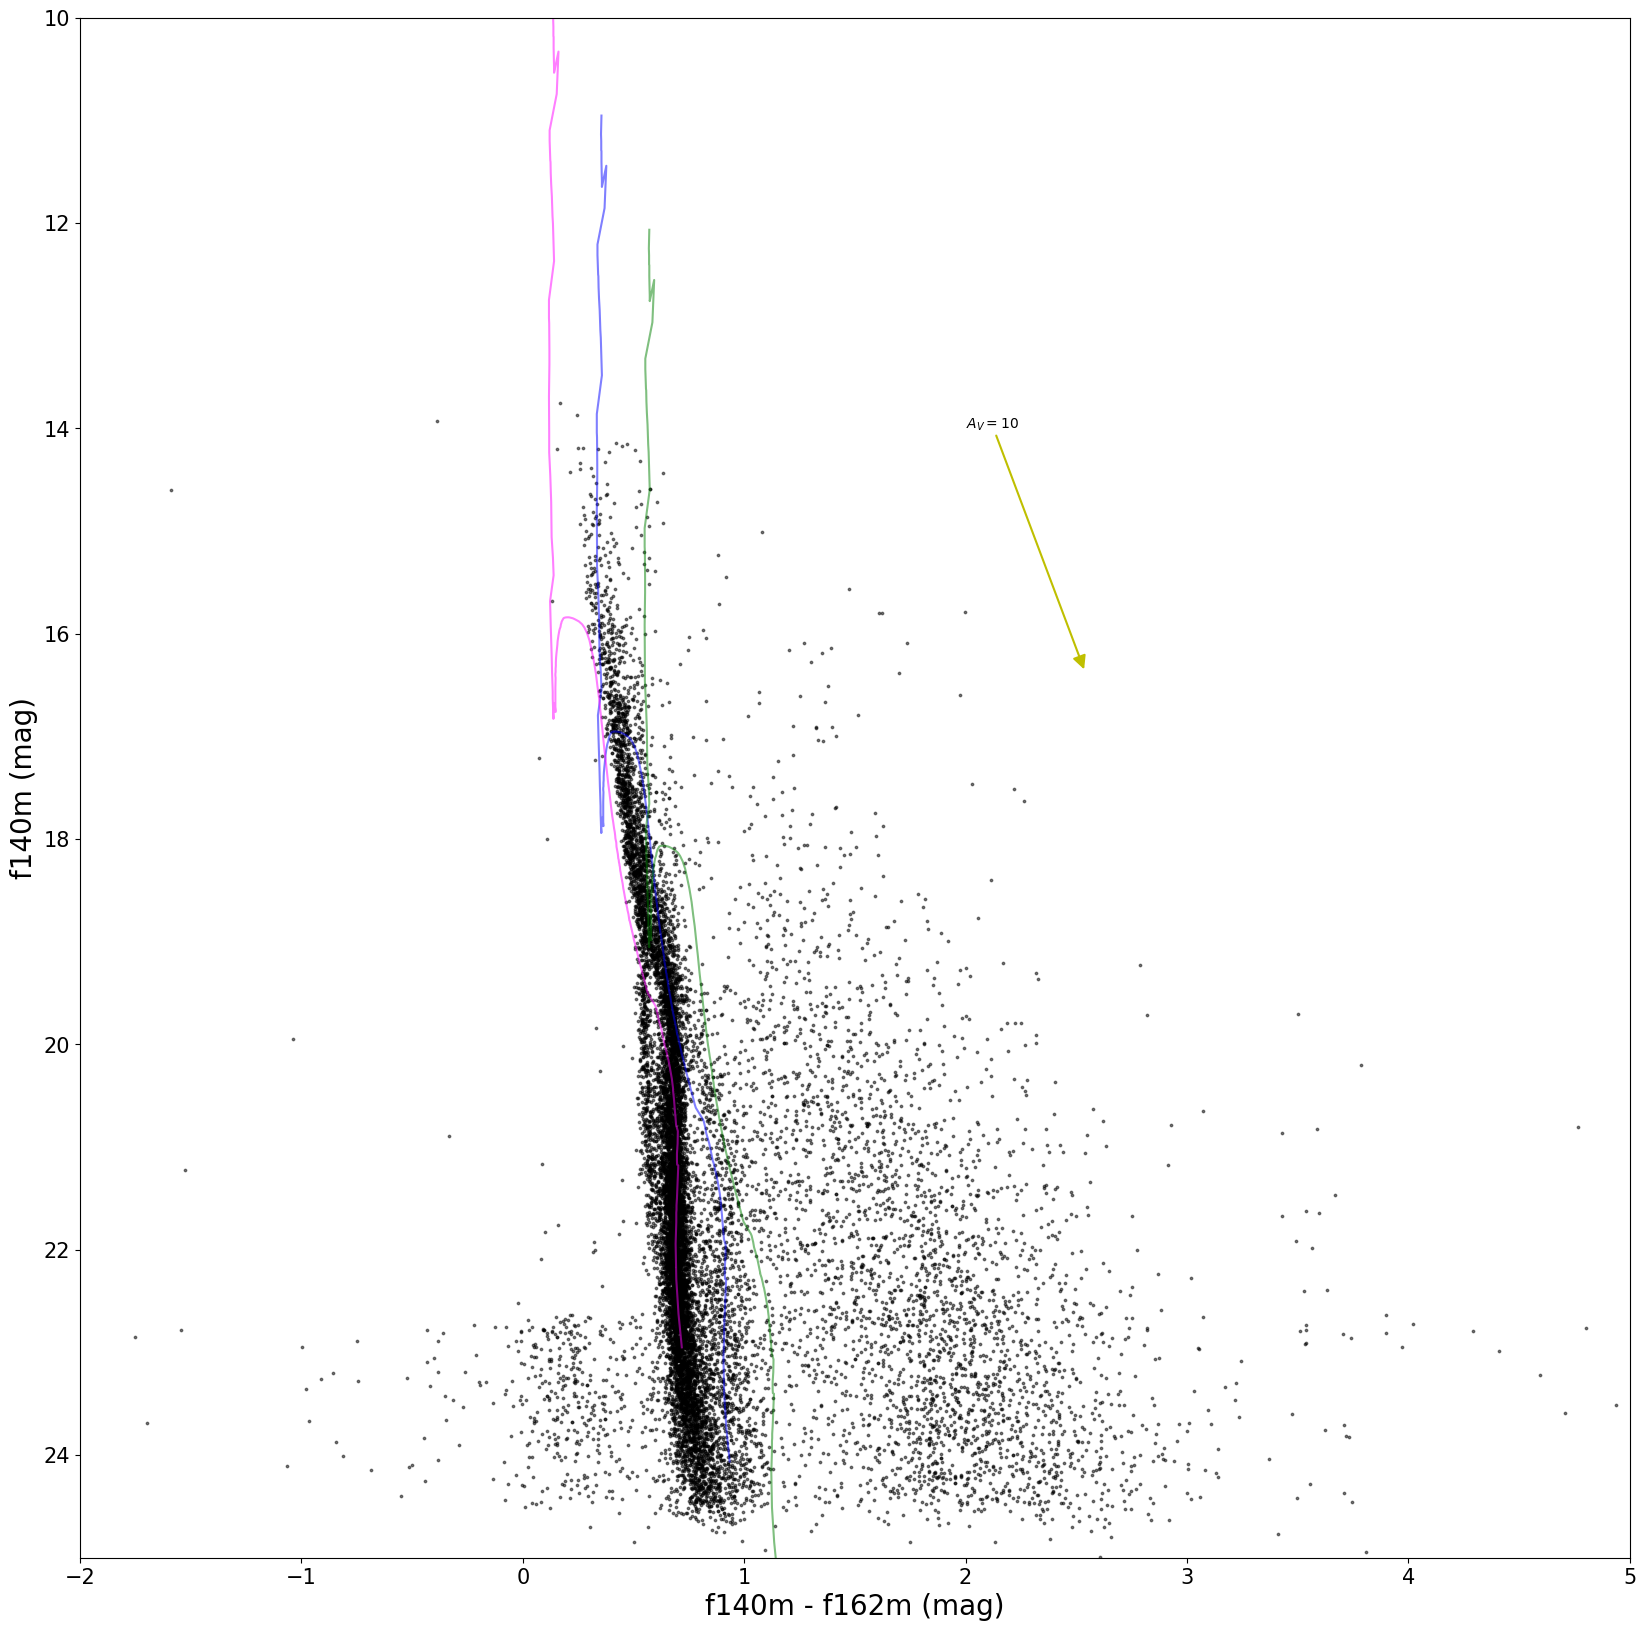

In [64]:
def plot_cmd(mag1, mag2, mags, xlim=(-2,5), ylim=(25,10)):
    x = (mags[mag1].value - mags[mag2].value)
    y = mags[mag1].value
    from astropy.coordinates import SkyCoord

    tab_gtc_matched = Table.read('/orange/adamginsburg/w51/TaehwaYoo/massive_star_table_jwstmatched.fits')
    tab_gtc_matched_skycoord = SkyCoord(ra=tab_gtc_matched['jwst_matched_ra']*u.deg, dec=tab_gtc_matched['jwst_matched_dec']*u.deg, frame='icrs')
    # For catalog
    ra = catalog['skycoord'].ra
    dec = catalog['skycoord'].dec
    valid = (~np.isnan(ra)) & (~np.isnan(dec))
    print(len(np.where(valid==False)[0]))
    catalog_skycoord_valid = SkyCoord(ra=ra[valid], dec=dec[valid], frame='icrs')
    # For GTC matched table
    ra_gtc = tab_gtc_matched['jwst_matched_ra']
    dec_gtc = tab_gtc_matched['jwst_matched_dec']
    print('ho')
    print(len(ra_gtc))
    valid_gtc = (~np.isnan(ra_gtc)) & (~np.isnan(dec_gtc))
    print(len(np.where(valid_gtc==False)[0]))
    tab_gtc_matched_skycoord_valid = SkyCoord(ra=ra_gtc[valid_gtc]*u.deg, dec=dec_gtc[valid_gtc]*u.deg, frame='icrs')
    print(len(tab_gtc_matched_skycoord_valid))
    # Now match only valid entries
    idx, d2d, d3d = catalog_skycoord_valid.match_to_catalog_sky(tab_gtc_matched_skycoord_valid)
    real_matched = d2d < 0.05*u.arcsec
    reverse_idx, reverse_d2d, reverse_d3d = tab_gtc_matched_skycoord_valid.match_to_catalog_sky(catalog_skycoord_valid)
    real_reverse_matched = reverse_d2d < 0.05*u.arcsec



    fig = plt.figure(figsize=(20,20))
    ax1 = fig.add_subplot(111)
    ax1.scatter(x, y, s=3, color='k', alpha=0.5, label='NIRCam catalog sources')
    #ax1.scatter(x[valid][idx][real_matched], y[valid][idx][real_matched], s=20, color='red', label='GTC matched sources')
    ax1.invert_yaxis()
    ageset=[6.0]
    for i, age in enumerate(ageset):
        idx_age = logage_av0 == age

        ax1.plot((mags_from_isochrone[mag1][idx_age]-mags_from_isochrone[mag2][idx_age]+(ext(1/1.4/u.um)-ext(1/1.62/u.um))*15), (mags_from_isochrone[mag1][idx_age]+(ext(1/1.4/u.um))*15) , color='blue', alpha=0.5)
        ax1.plot((mags_from_isochrone[mag1][idx_age]-mags_from_isochrone[mag2][idx_age]+(ext(1/1.4/u.um)-ext(1/1.62/u.um))*20), (mags_from_isochrone[mag1][idx_age]+(ext(1/1.4/u.um))*20) , color='green', alpha=0.5)
        ax1.plot((mags_from_isochrone[mag1][idx_age]-mags_from_isochrone[mag2][idx_age]+(ext(1/1.4/u.um)-ext(1/1.62/u.um))*10), (mags_from_isochrone[mag1][idx_age]+(ext(1/1.4/u.um))*10) , color='magenta', alpha=0.5)
    ax1.set_xlabel(f'{mag1} - {mag2} (mag)')
    ax1.set_ylabel(f'{mag1} (mag)')
    ax1.set_xlim(xlim[0], xlim[1])
    ax1.set_ylim(ylim[0], ylim[1])
    plot_extvec_cmd(ax1,mag1, mag2, ext=RL85_MWGC(), extvec_scale=10,
                    start=(2, 14),
                    color='y', head_width=0.5)
    
plot_cmd('f140m', 'f162m', mags)



0
ho
218
0
102


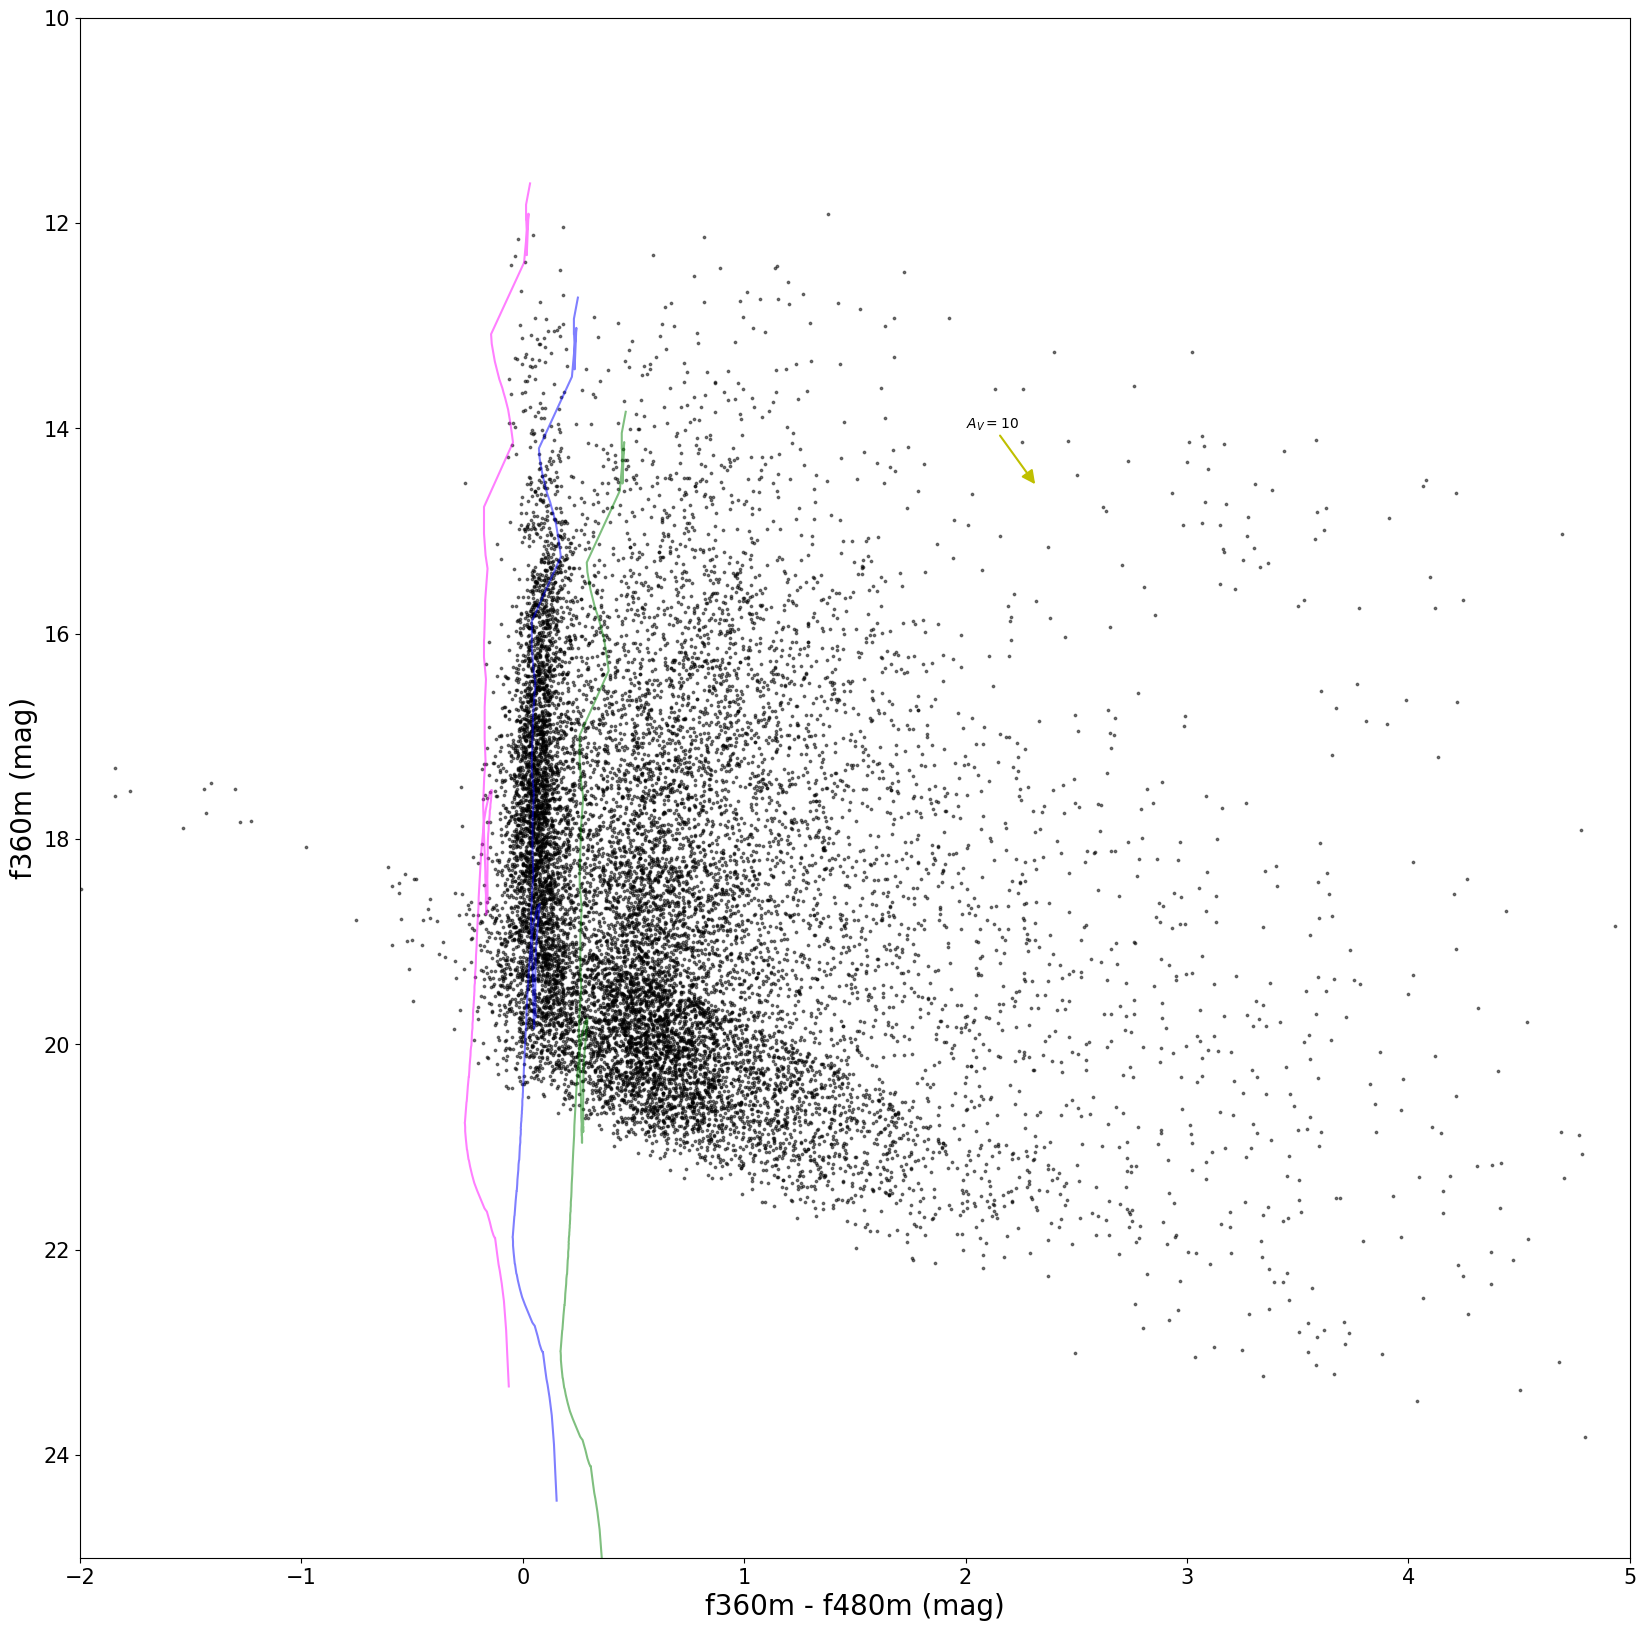

In [65]:
plot_cmd('f360m', 'f480m', mags)

0
ho
218
0
102


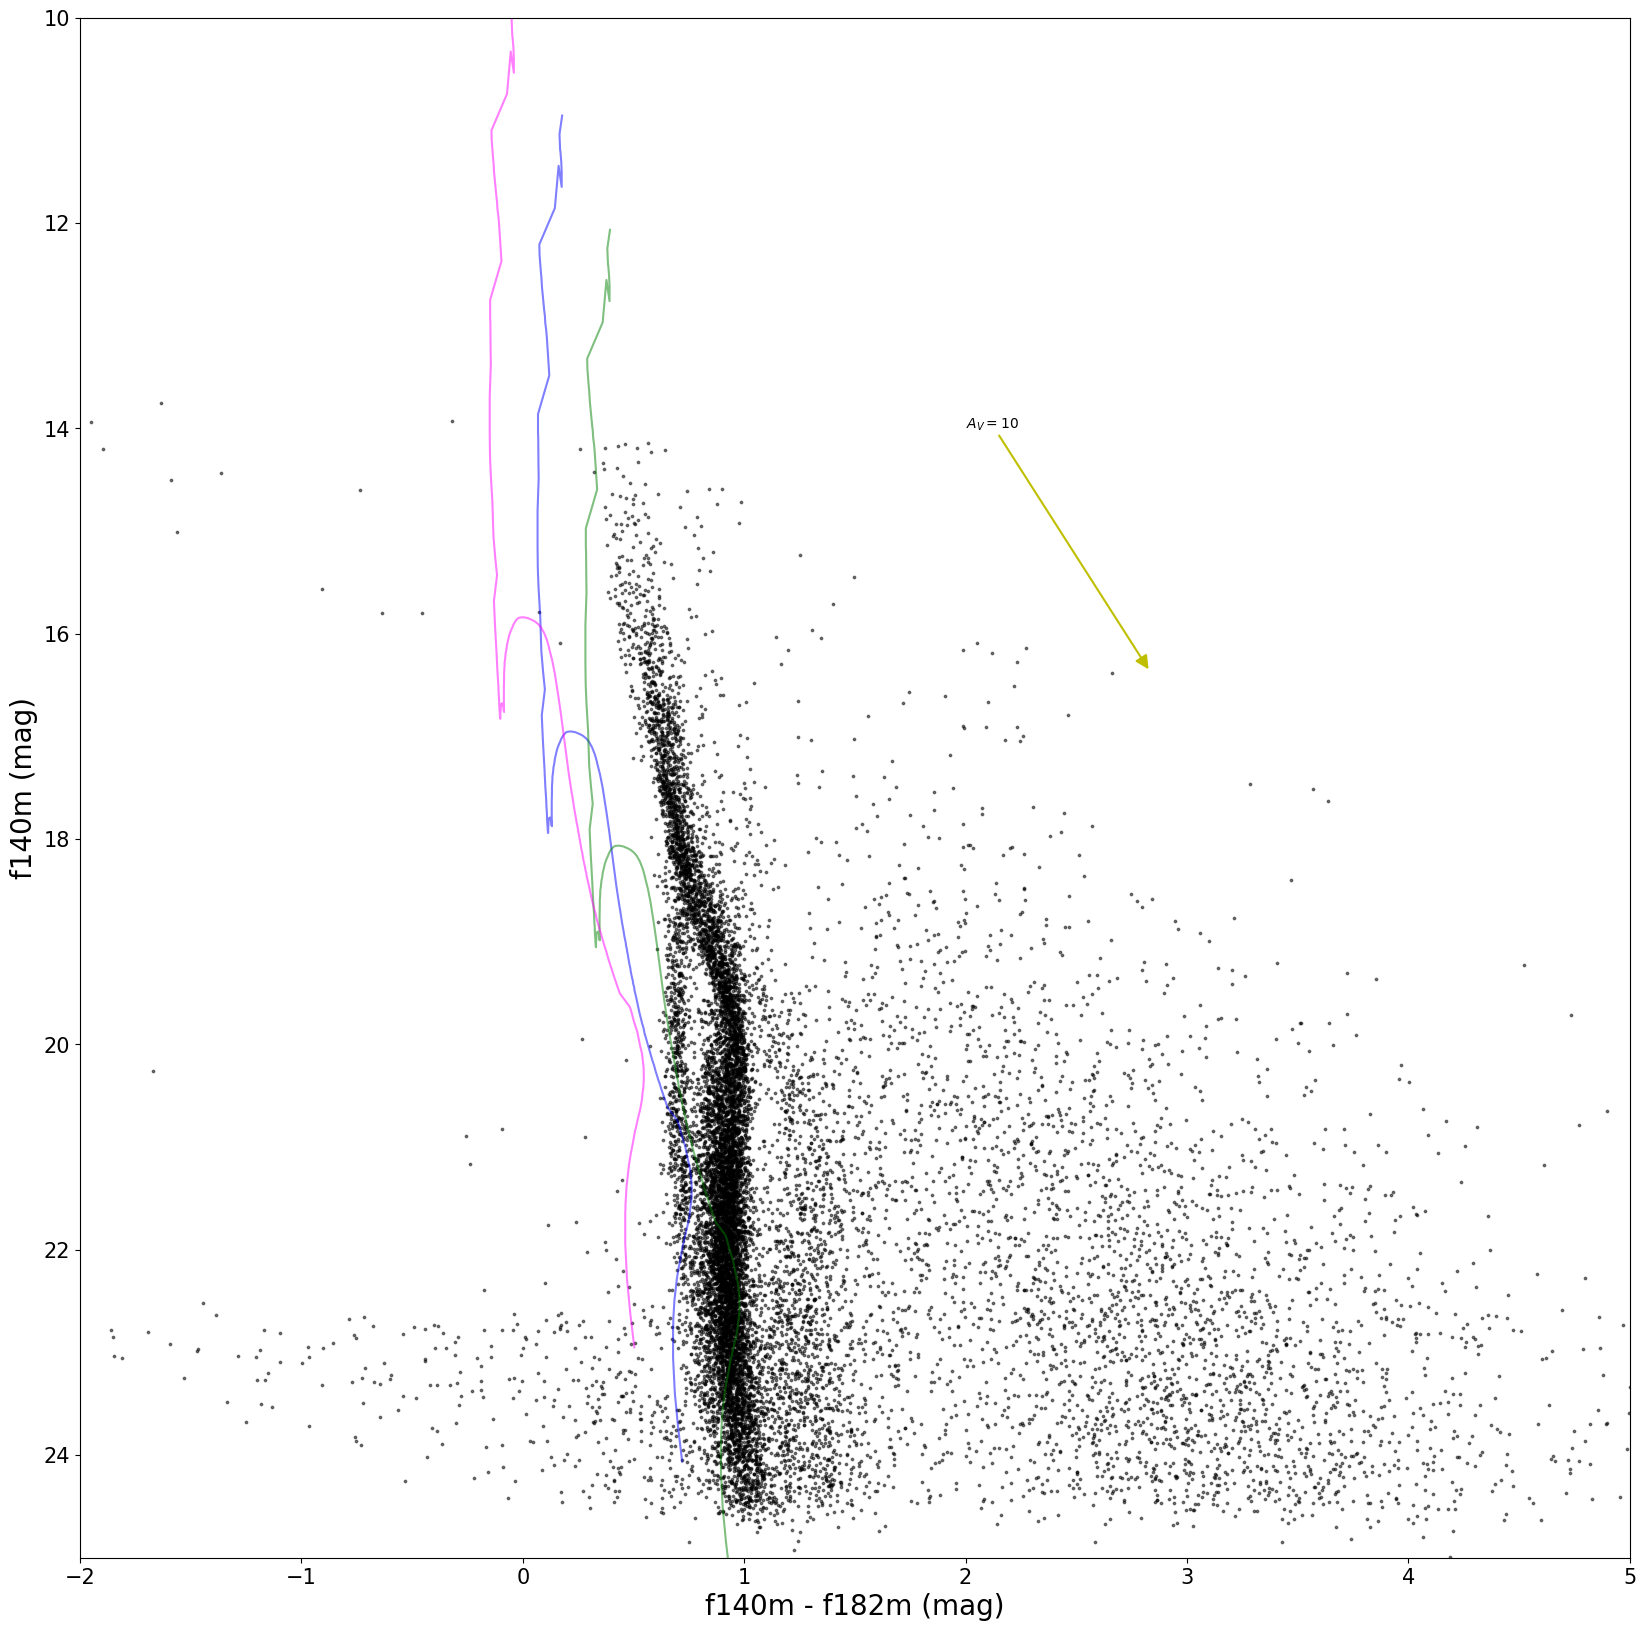

In [66]:
plot_cmd('f140m', 'f182m', mags)


0
ho
218
0
102


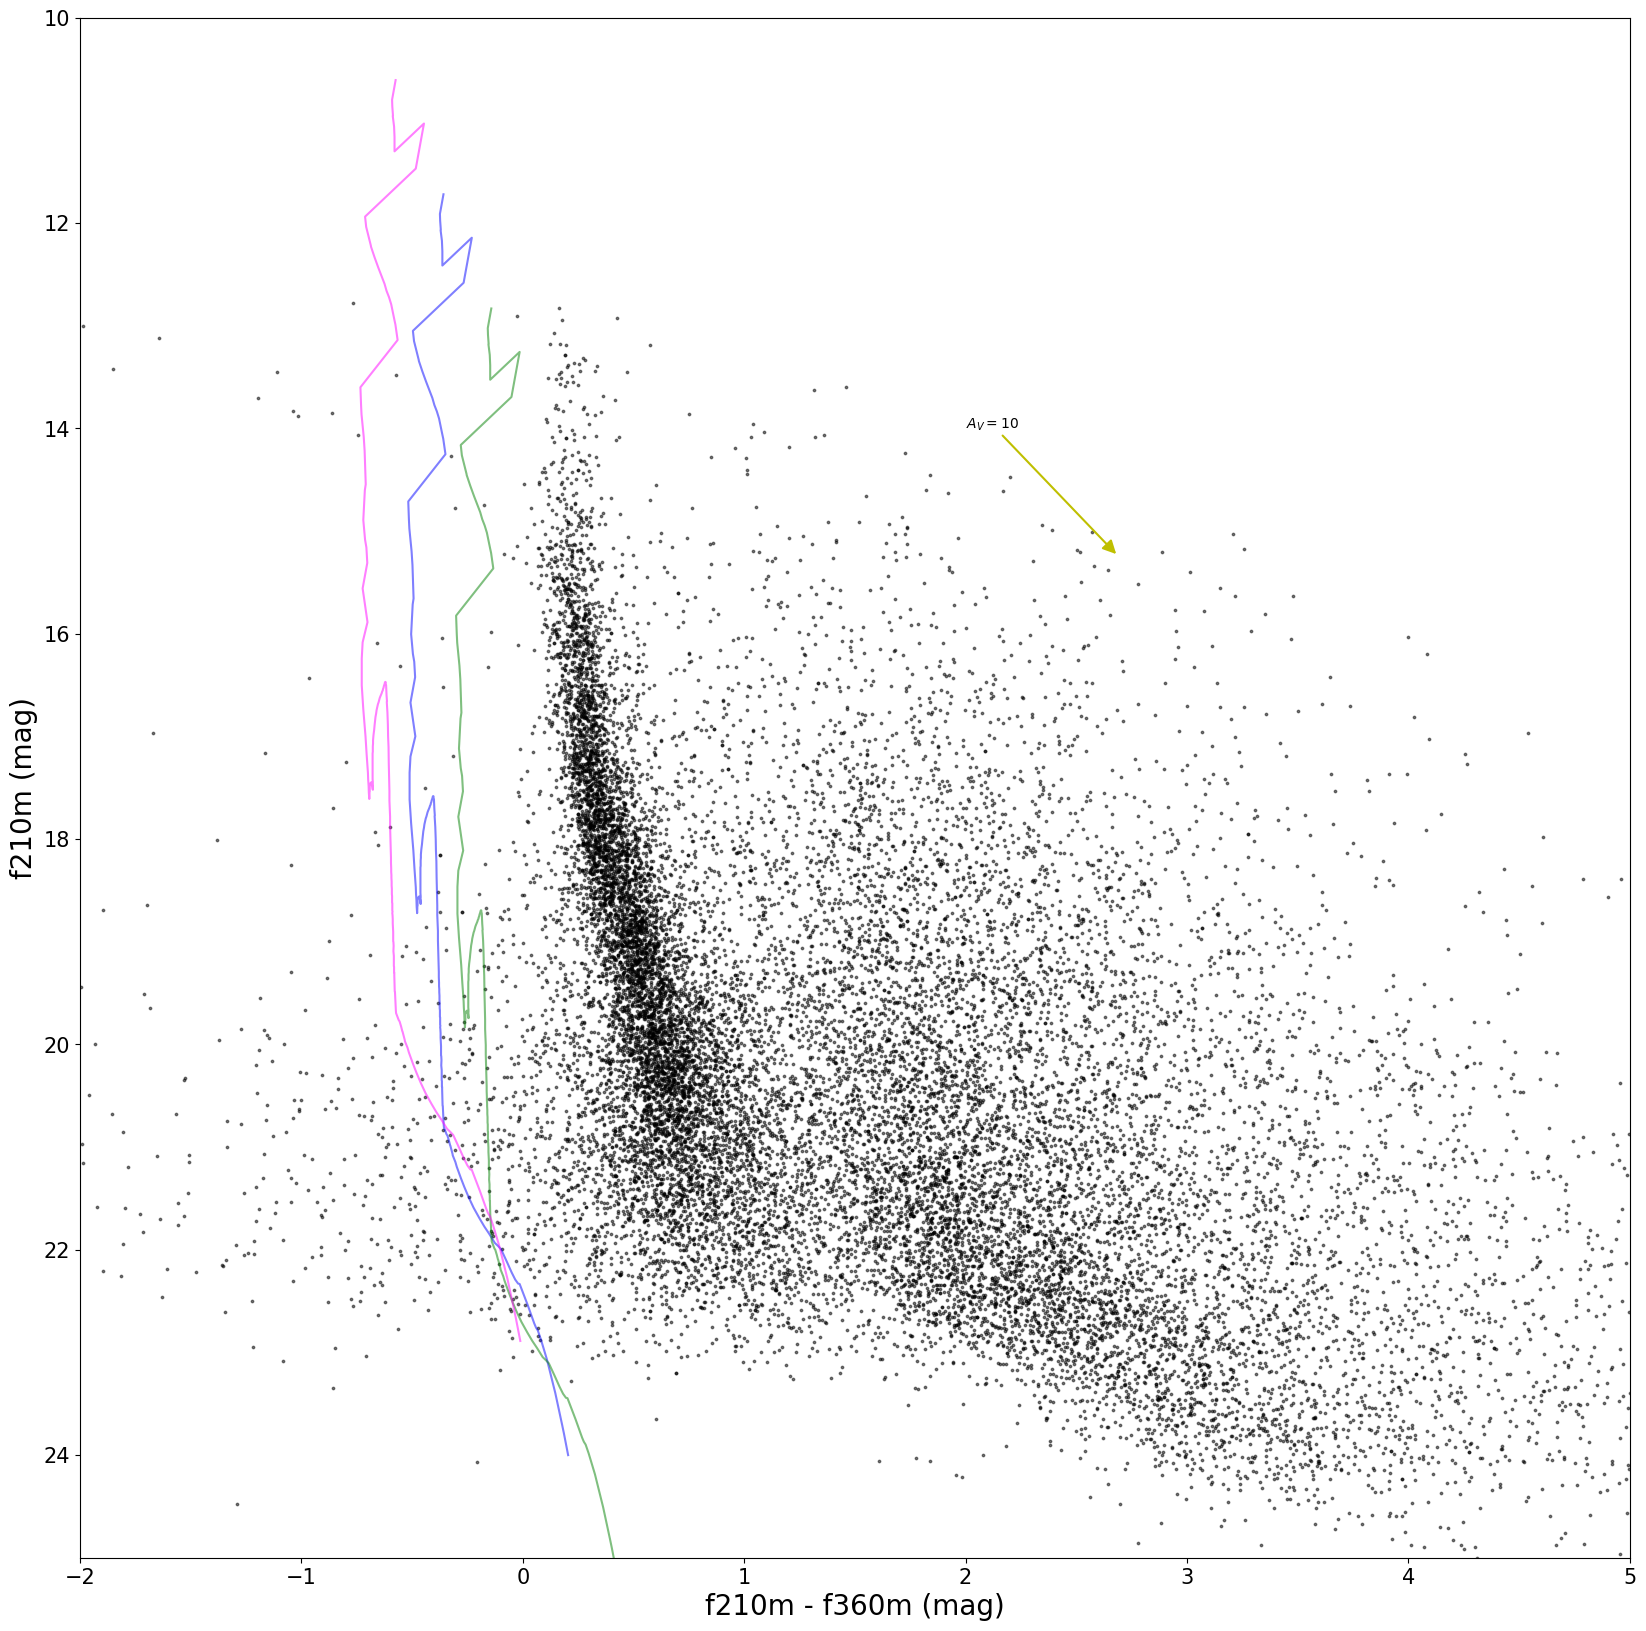

In [67]:
plot_cmd('f210m', 'f360m',mags)

0
ho
218
0
102


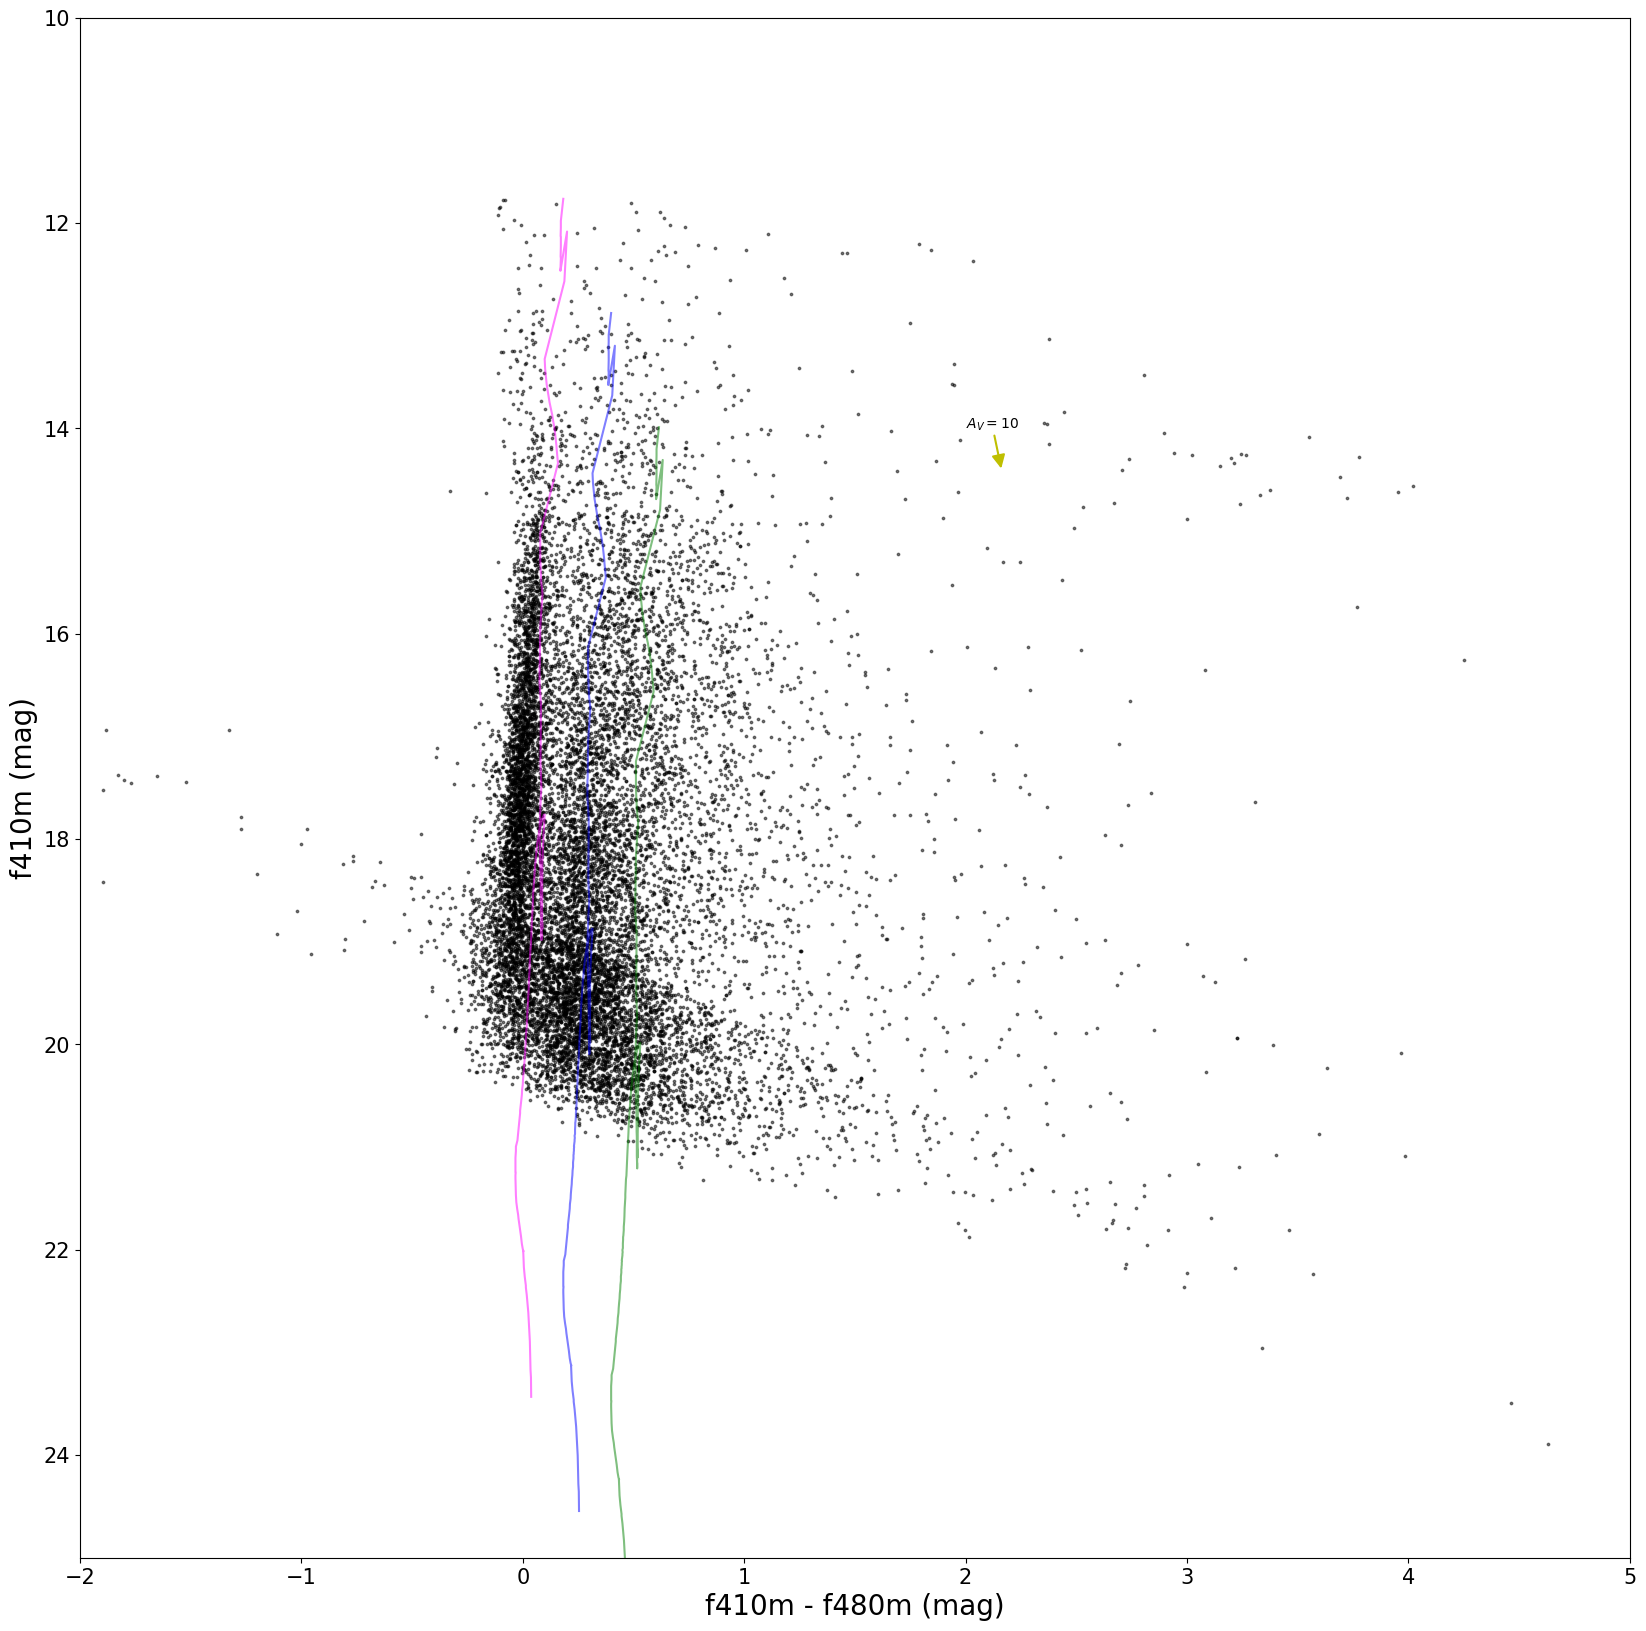

In [68]:
plot_cmd('f410m', 'f480m', mags)

0
ho
218
0
102


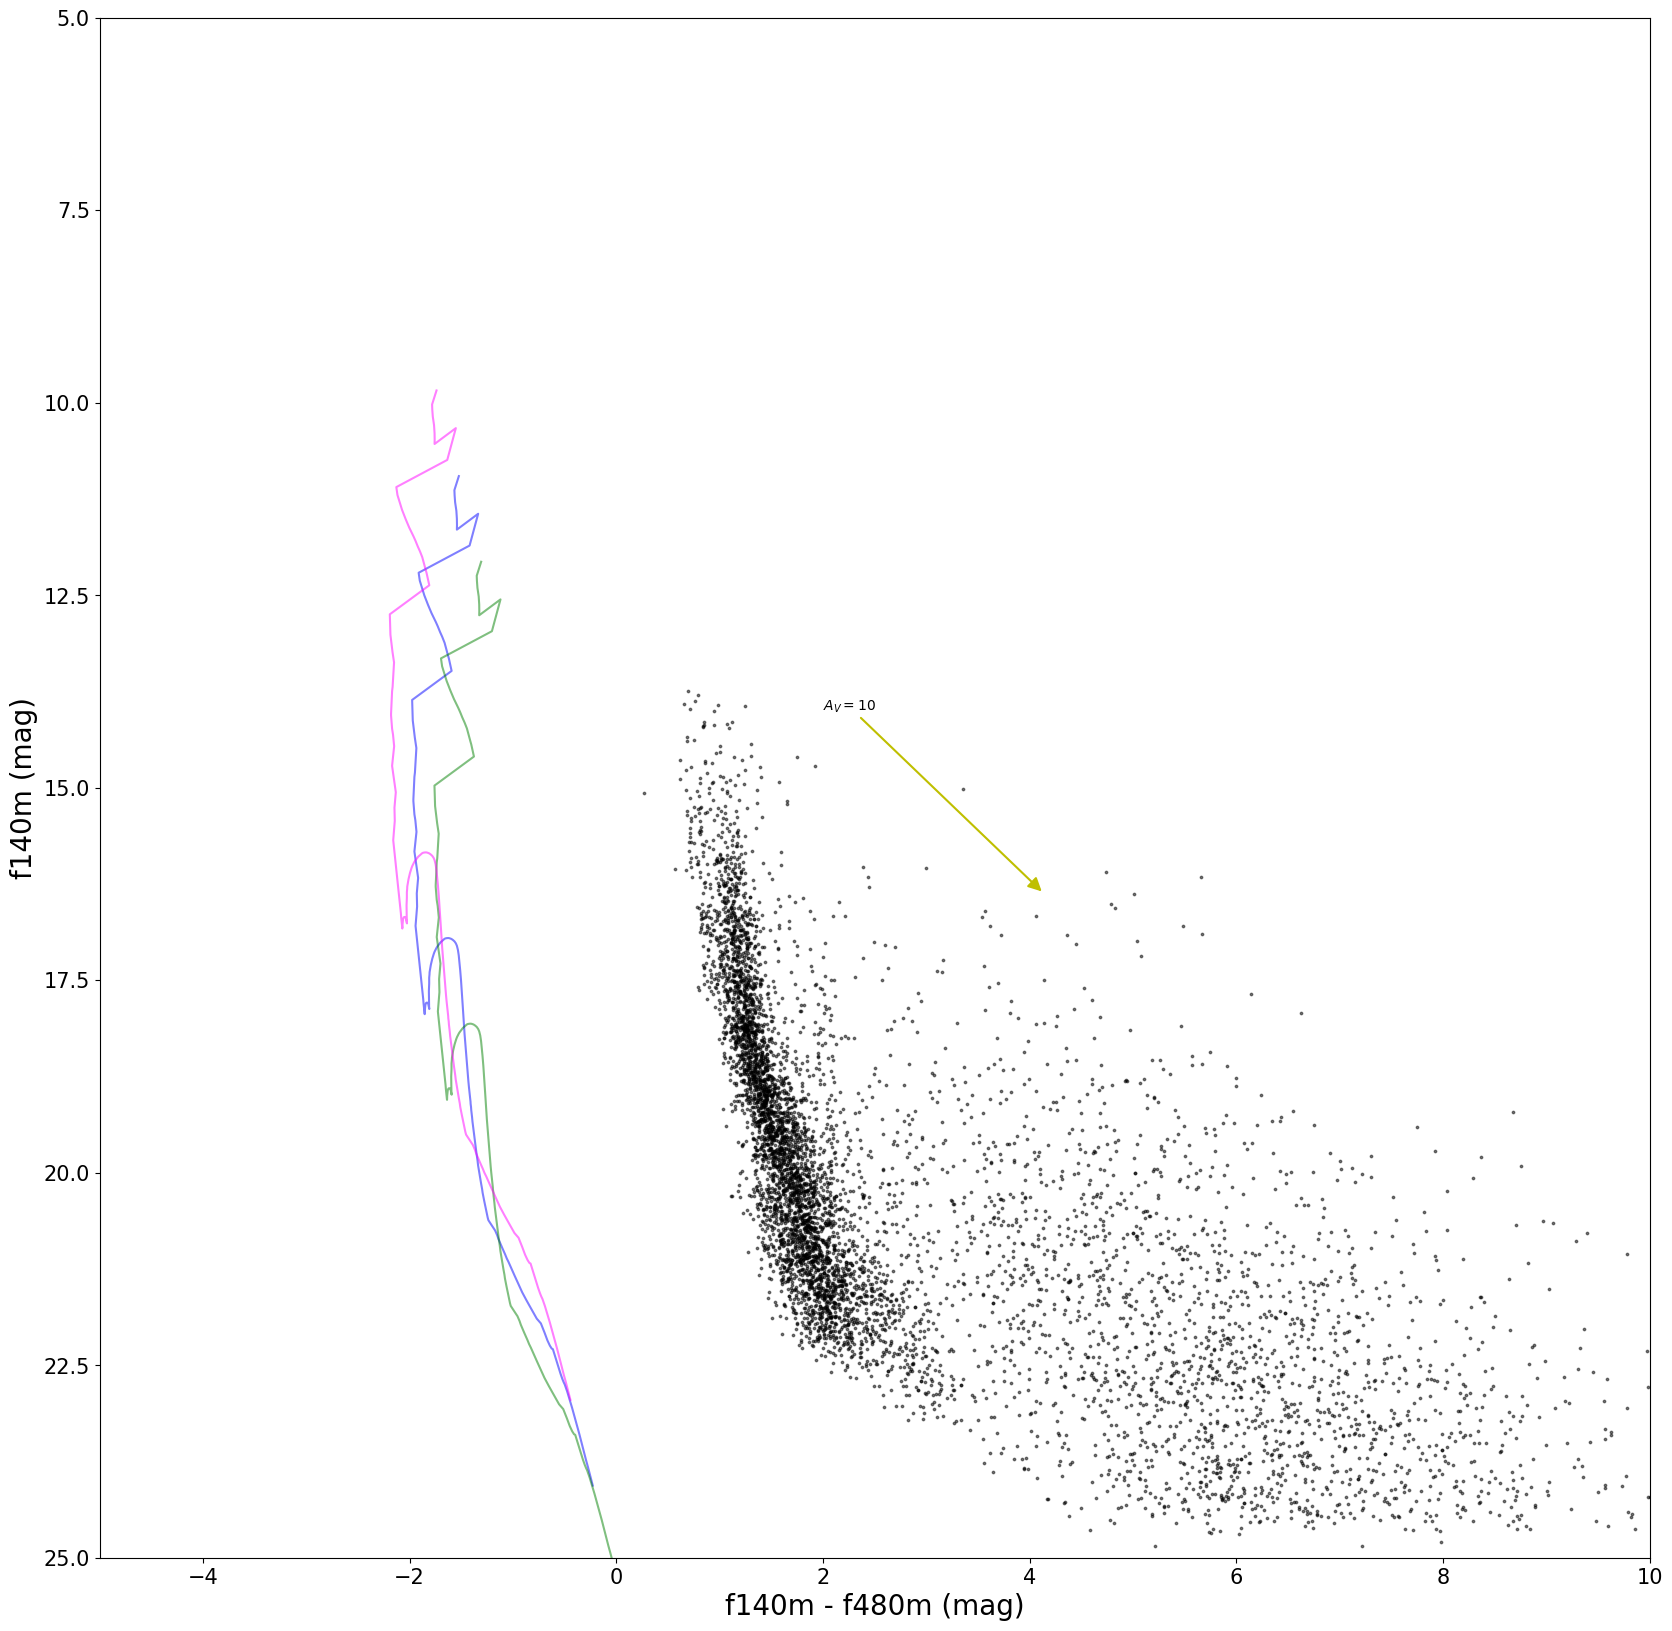

In [69]:
plot_cmd('f140m', 'f480m', mags, xlim=(-5,10), ylim=(25,5))
